In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import figure

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [23]:
df_sex = df['Sex'].value_counts()
df_sex

Sex
male      577
female    314
Name: count, dtype: int64

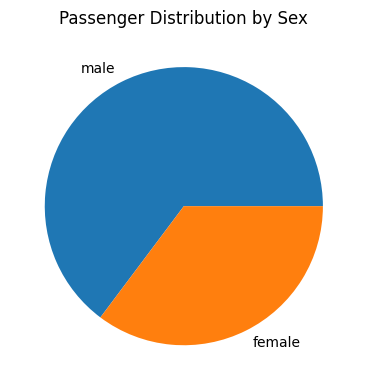

In [38]:
plt.figure(figsize=(6,4))
plt.pie(df_sex.values, labels=df_sex.index)
plt.title('Passenger Distribution by Sex')
plt.tight_layout()

In [43]:
fare_sum_by_sex = df.groupby('Sex')['Fare'].sum()

fare_sum_by_sex

Sex
female    13966.6628
male      14727.2865
Name: Fare, dtype: float64

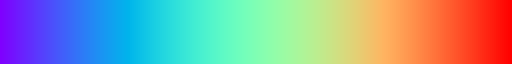

In [45]:
plt.get_cmap('rainbow')

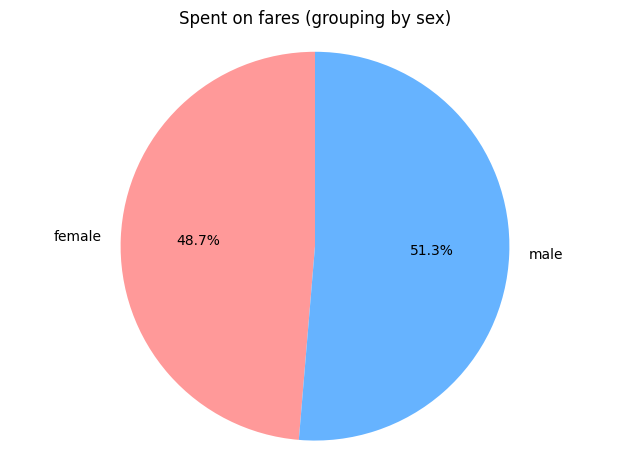

In [55]:
plt.pie(fare_sum_by_sex, autopct='%0.1f%%', labels=fare_sum_by_sex.index, colors=['#ff9999', '#66b3ff'], startangle=90)
plt.title('Spent on fares (grouping by sex)')
plt.axis('equal')
plt.tight_layout()

In [63]:
survived_sum = df.groupby('Survived')['PassengerId'].count()
survived_sum

Survived
0    549
1    342
Name: PassengerId, dtype: int64

Text(0.5, 1.0, 'Survived')

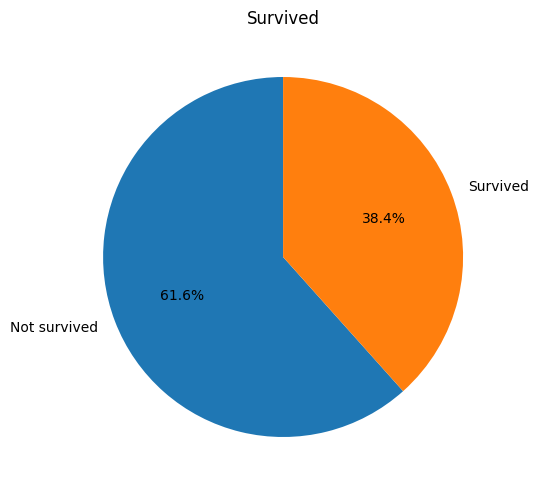

In [70]:
plt.pie(survived_sum, labels=['Not survived', 'Survived'], autopct='%0.1f%%', startangle=90)
plt.tight_layout()
plt.title('Survived')

In [73]:
df_sex_survived = df.groupby(['Sex', 'Survived'])['PassengerId'].count().unstack(fill_value=0)
df_sex_survived

Survived,0,1
Sex,,
female,81,233
male,468,109


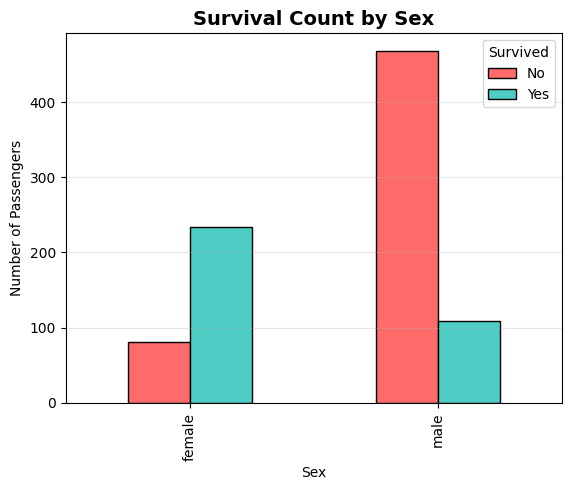

In [87]:
df_sex_survived.plot(kind='bar', color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
plt.title('Survival Count by Sex', fontsize=14, fontweight='bold')
plt.xlabel('Sex')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.3)